# problem: predict the daily drinking amount from the features


## Import libraries and laod data

In [1]:
# for the data and plotting
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io.arff import loadarff # to convert the data file into csv


# for making the models
from sklearn.model_selection import train_test_split # split the dataframe into test and split sections
from sklearn.metrics import mean_squared_error # measure the accuracy of the model
from sklearn.metrics import root_mean_squared_error # measure the accuracy of the model
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
    
    # random forest
from sklearn.ensemble import RandomForestClassifier 
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import PoissonRegressor


In [2]:
## so that the graphs do not pop up in a new window
%matplotlib inline

In [3]:
# get theh data
data = loadarff('dataset_8_liver-disorders.arff')

# Convert to DataFrame
df = pd.DataFrame(data)

## Data Exploration

### looking at top of the dataframe

In [4]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,335,336,337,338,339,340,341,342,343,344
0,"[85.0, 92.0, 45.0, 27.0, 31.0, 0.0, b'1']","[85.0, 64.0, 59.0, 32.0, 23.0, 0.0, b'2']","[86.0, 54.0, 33.0, 16.0, 54.0, 0.0, b'2']","[91.0, 78.0, 34.0, 24.0, 36.0, 0.0, b'2']","[87.0, 70.0, 12.0, 28.0, 10.0, 0.0, b'2']","[98.0, 55.0, 13.0, 17.0, 17.0, 0.0, b'2']","[88.0, 62.0, 20.0, 17.0, 9.0, 0.5, b'1']","[88.0, 67.0, 21.0, 11.0, 11.0, 0.5, b'1']","[92.0, 54.0, 22.0, 20.0, 7.0, 0.5, b'1']","[90.0, 60.0, 25.0, 19.0, 5.0, 0.5, b'1']",...,"[92.0, 41.0, 37.0, 22.0, 37.0, 10.0, b'1']","[86.0, 123.0, 20.0, 25.0, 23.0, 10.0, b'2']","[91.0, 93.0, 35.0, 34.0, 37.0, 10.0, b'2']","[87.0, 87.0, 15.0, 23.0, 11.0, 10.0, b'2']","[87.0, 56.0, 52.0, 43.0, 55.0, 10.0, b'2']","[99.0, 75.0, 26.0, 24.0, 41.0, 12.0, b'1']","[96.0, 69.0, 53.0, 43.0, 203.0, 12.0, b'2']","[98.0, 77.0, 55.0, 35.0, 89.0, 15.0, b'1']","[91.0, 68.0, 27.0, 26.0, 14.0, 16.0, b'1']","[98.0, 99.0, 57.0, 45.0, 65.0, 20.0, b'1']"
1,mcv,alkphos,sgpt,sgot,gammagt,drinks,selector,None,None,None,...,None,None,None,None,None,None,None,None,None,None


### looking at the data types

In [5]:
df.iloc[0,0]

#data types below explained
#   '<f8' → little-endian 64-bit float
#   S1 -> byte string of length 1

np.void((85.0, 92.0, 45.0, 27.0, 31.0, 0.0, b'1'), dtype=[('mcv', '<f8'), ('alkphos', '<f8'), ('sgpt', '<f8'), ('sgot', '<f8'), ('gammagt', '<f8'), ('drinks', '<f8'), ('selector', 'S1')])

##### get  a table where each column is an attribute of all the paitiens instead of one with all the attributes of one patient in one cell 

In [6]:
first_row = df.iloc[0] 

In [7]:
df_mvc = pd.DataFrame(columns=['mcv'])
df_alkphos = pd.DataFrame(columns=['alkphos'])
df_sgpt = pd.DataFrame(columns=['sgpt'])
df_sgot = pd.DataFrame(columns=['sgot'])
df_gammagt = pd.DataFrame(columns=['gammagt'])
df_drinks = pd.DataFrame(columns=['drinks'])
df_selector = pd.DataFrame(columns=['selector'])

#make a dataframe where each attribute from each patient will be kept

In [8]:
for row in first_row: # for each patient in the first wor
    for name in row.dtype.names:# get the name of the column in the tuple
        match name:
            case 'mcv':
                new_row = {'mcv': row[name]} # safe the value in the tuple
                df_mvc.loc[len(df_mvc)] = new_row # add the value in the tuple into the specified datafram 

            case 'alkphos':
                new_row = {'alkphos': row[name]}
                df_alkphos.loc[len(df_alkphos)] = new_row

            case 'sgpt':
                new_row = {'sgpt': row[name]}
                df_sgpt.loc[len(df_sgpt)] = new_row

            case 'sgot':
                new_row = {'sgot': row[name]}
                df_sgot.loc[len(df_sgot)] = new_row

            case 'gammagt':
                new_row = {'gammagt': row[name]}
                df_gammagt.loc[len(df_gammagt)] = new_row

            case 'drinks':
                new_row = {'drinks': row[name]}
                df_drinks.loc[len(df_drinks)] = new_row
            
            case 'selector':
                new_row = {'selector': row[name]}
                df_selector.loc[len(df_selector)] = new_row

            case _:
                print(f"something is wrong and i know you can fix it.\nhere are the value name:{name}, row[name]:{row[name]}")
        

In [9]:
# check that the datafram is filled and is the same length as the width of the main dataframe 
df_mvc 


,mcv
0,85.0
1,85.0
2,86.0
3,91.0
4,87.0
...,...
340,99.0
341,96.0
342,98.0
343,91.0


In [10]:
df_alkphos 


,alkphos
0,92.0
1,64.0
2,54.0
3,78.0
4,70.0
...,...
340,75.0
341,69.0
342,77.0
343,68.0


In [11]:
df_sgpt 


,sgpt
0,45.0
1,59.0
2,33.0
3,34.0
4,12.0
...,...
340,26.0
341,53.0
342,55.0
343,27.0


In [12]:
df_sgot 


,sgot
0,27.0
1,32.0
2,16.0
3,24.0
4,28.0
...,...
340,24.0
341,43.0
342,35.0
343,26.0


In [13]:
df_gammagt 


,gammagt
0,31.0
1,23.0
2,54.0
3,36.0
4,10.0
...,...
340,41.0
341,203.0
342,89.0
343,14.0


In [14]:
df_drinks 


,drinks
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
340,12.0
341,12.0
342,15.0
343,16.0


In [15]:
df_selector 

,selector
0,b'1'
1,b'2'
2,b'2'
3,b'2'
4,b'2'
...,...
340,b'1'
341,b'2'
342,b'1'
343,b'1'


In [16]:
## join all the dataframes into one datafram
result = pd.concat([df_mvc,
                    df_alkphos,
                    df_sgpt, 
                    df_sgot, 
                    df_gammagt, 
                    df_drinks, 
                    df_selector
                    ]
                    ,
                      axis=1)


In [17]:
result
# check if it worked

,mcv,alkphos,sgpt,sgot,gammagt,drinks,selector
0,85.0,92.0,45.0,27.0,31.0,0.0,b'1'
1,85.0,64.0,59.0,32.0,23.0,0.0,b'2'
2,86.0,54.0,33.0,16.0,54.0,0.0,b'2'
3,91.0,78.0,34.0,24.0,36.0,0.0,b'2'
4,87.0,70.0,12.0,28.0,10.0,0.0,b'2'
...,...,...,...,...,...,...,...
340,99.0,75.0,26.0,24.0,41.0,12.0,b'1'
341,96.0,69.0,53.0,43.0,203.0,12.0,b'2'
342,98.0,77.0,55.0,35.0,89.0,15.0,b'1'
343,91.0,68.0,27.0,26.0,14.0,16.0,b'1'


### check for missing values

In [18]:
result.describe()

,mcv,alkphos,sgpt,sgot,gammagt,drinks
count,345.000000,345.000000,345.000000,345.000000,345.000000,345.000000
mean,90.159420,69.869565,30.405797,24.643478,38.284058,3.455072
std,4.448096,18.347670,19.512309,10.064494,39.254616,3.337835
min,65.000000,23.000000,4.000000,5.000000,5.000000,0.000000
25%,87.000000,57.000000,19.000000,19.000000,15.000000,0.500000
50%,90.000000,67.000000,26.000000,23.000000,25.000000,3.000000
75%,93.000000,80.000000,34.000000,27.000000,46.000000,6.000000
max,103.000000,138.000000,155.000000,82.000000,297.000000,20.000000


In [19]:
result.info

<bound method DataFrame.info of       mcv  alkphos  sgpt  sgot  gammagt  drinks selector
0    85.0     92.0  45.0  27.0     31.0     0.0     b'1'
1    85.0     64.0  59.0  32.0     23.0     0.0     b'2'
2    86.0     54.0  33.0  16.0     54.0     0.0     b'2'
3    91.0     78.0  34.0  24.0     36.0     0.0     b'2'
4    87.0     70.0  12.0  28.0     10.0     0.0     b'2'
..    ...      ...   ...   ...      ...     ...      ...
340  99.0     75.0  26.0  24.0     41.0    12.0     b'1'
341  96.0     69.0  53.0  43.0    203.0    12.0     b'2'
342  98.0     77.0  55.0  35.0     89.0    15.0     b'1'
343  91.0     68.0  27.0  26.0     14.0    16.0     b'1'
344  98.0     99.0  57.0  45.0     65.0    20.0     b'1'

[345 rows x 7 columns]>

### check for ouliters

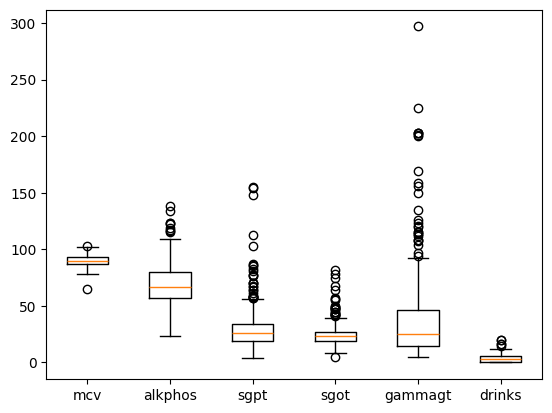

In [20]:

plt.boxplot([result['mcv'], result['alkphos'], result['sgpt'], result['sgot'], result['gammagt'], result['drinks']])
# basic plot


plt.xticks([1, 2, 3, 4, 5, 6], ['mcv', 'alkphos', 'sgpt', 'sgot', 'gammagt', 'drinks']) 
#adding all the columns in the x-axis

plt.show()

EXPLANTION: seems like gammagt and alkhos have negative correlation the rest have no correlation

### find the ccorrelation of the attributes to the 'drinks column by...
*computing the standard correlation coefficient (also called Pearson’s r) between every pair of numerical attributes using the
corr() method*

In [21]:
corr_matrix = result.corr(numeric_only=True)

corr_matrix["drinks"].sort_values(ascending=False)
#The correlation coefficient ranges from –1 to 1. When it is close to 1, it means that
# there is a strong positive correlation; for example, the median house value tends to
# go up when the median income goes up. When the coefficient is close to –1, it means
# that there is a strong negative correlation; 

# EXPLANTION: in this case there is barely any correlation 

drinks     1.000000
gammagt    0.341224
mcv        0.312680
sgot       0.279588
sgpt       0.206848
alkphos    0.100796
Name: drinks, dtype: float64

##### ...because there is no correlation wanted to check if there is something going on with the distribution of the drinks column

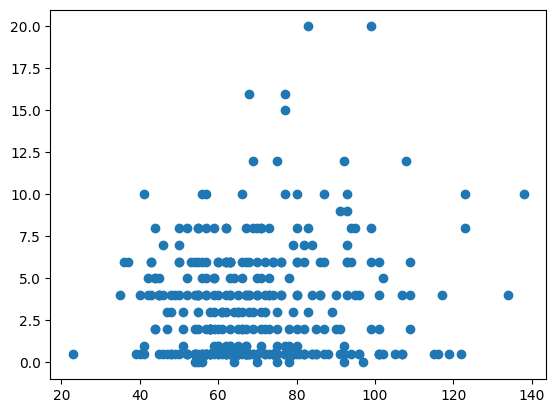

In [22]:
plt.scatter(result['alkphos'], result['drinks'])
plt.show()

EXPLANATION: 

Most of your target (y) values are small/low, and only a few are high.

1. Your drinks is skewed - This is very common in real datasets.
2. Highly skewed targets can make the model: focus too much on large outliers predict poorly for most points produce unstable coefficients


#### Check the target(drinks) distribution with a histogram

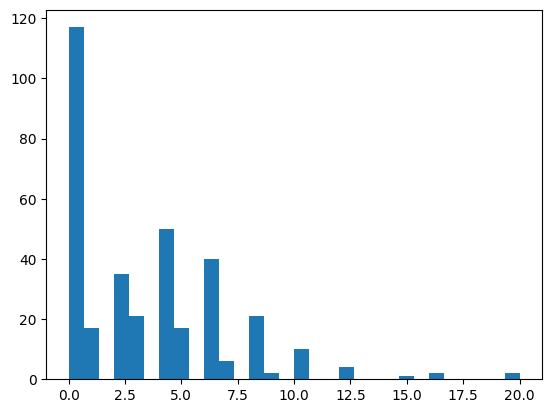

In [23]:
import matplotlib.pyplot as plt

plt.hist(result['drinks'], bins=30)
plt.show()

EXPLANATION: the target is right-skewed.


the majority of points are compressed near the bottom
a few large values dominate the error
the relationship looks nonlinear


## Prepare data


#### ...to fix this try to predict log(y) instead becaue it compresses huge values.



In [24]:
# # #because of the skenewness of more than one attribute to one side we need to o before you scale the feature, you should first
# # transform it to shrink the heavy tail, and if possible to make the distribution roughly symmetrical

# a common way to do this for positive features with a heavy
# tail to the right is to replace the feature with its square root (or raise the feature to a power between 0 and 1). If the feature has a really long and heavy tail, such as a power law distribution, then replacing the feature with its logarithm may help. 

In [25]:
import numpy as np

y_log = np.log1p(result['drinks'])

In [26]:
# check the correlation between the log of drinks and the other attributes
result['log_drinks'] = y_log
corr_matrix = result.corr(numeric_only=True)
corr_matrix["log_drinks"].sort_values(ascending=False)

log_drinks    1.000000
drinks        0.931777
gammagt       0.306640
mcv           0.302574
sgot          0.249142
sgpt          0.163618
alkphos       0.042772
Name: log_drinks, dtype: float64

#### checking if relationships between drinks and other attributes using a scatter graph so see the distriubtion of data

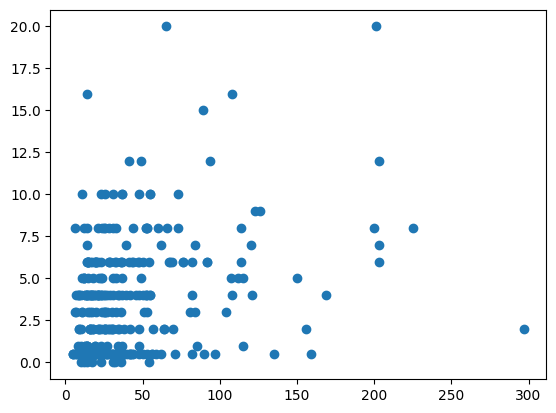

In [27]:
plt.scatter(result['gammagt'], result['drinks'])
plt.show()

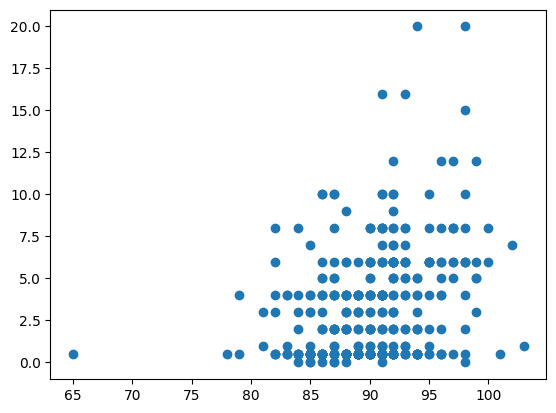

In [28]:
plt.scatter(result['mcv'], result['drinks'])
plt.show()

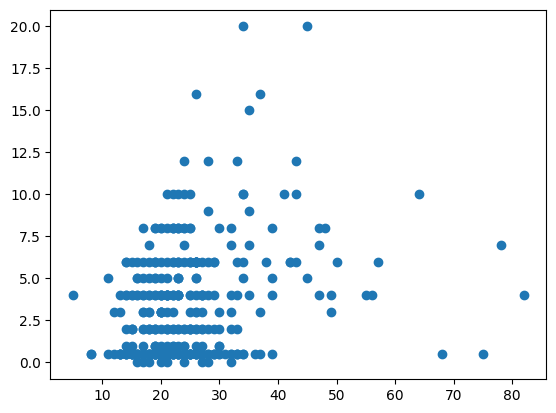

In [29]:
plt.scatter(result['sgot'], result['drinks'])
plt.show()

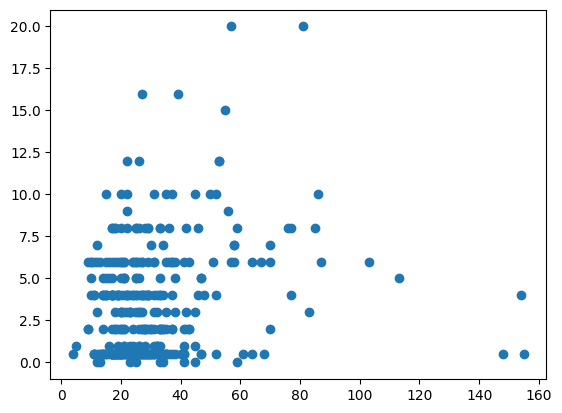

In [30]:
plt.scatter(result['sgpt'], result['drinks'])
plt.show()

#### check if log drinks makes the tail significantly smaller


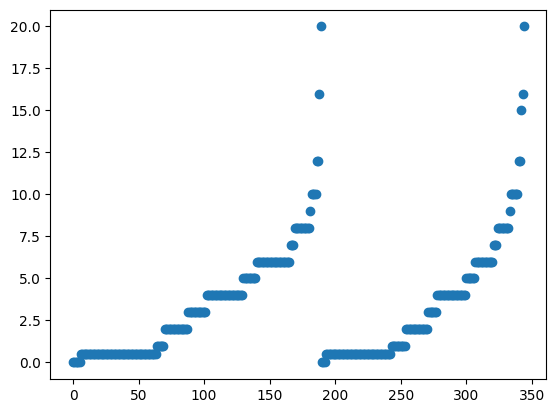

In [31]:

plt.scatter(result.index,result['drinks'])
plt.show()

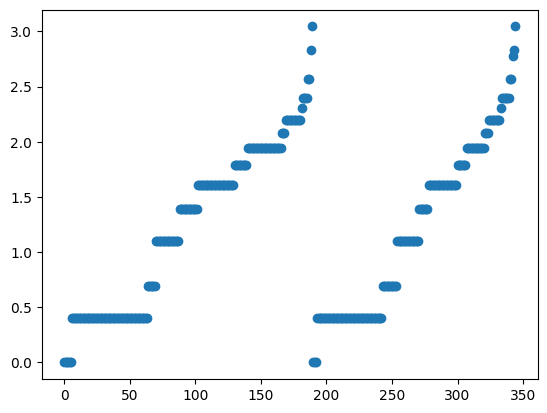

In [32]:
plt.scatter(result.index,result['log_drinks'])
plt.show()

### log did not work so i am going to try bucketizing


Another approach to handle heavy-tailed features consists in bucketizing the feature.

This means chopping its distribution into roughly equal-sized buckets, and replacing each feature value with the index of the bucket it belongs to


Bucketizing with
equal-sized buckets results in a feature with an almost uniform distribution, so there’s
no need for further scaling, or you can just divide by the number of buckets to force
the values to the 0–1 range.

In [33]:
bucketized_results = pd.DataFrame()
all_bins = {}

for col in result.select_dtypes(include='number').columns: # for all the number type columns
    
    # Create buckets and get bin edges
    buckets, bins = pd.qcut(
        result[col],
        q=80,
        labels=False,
        retbins=True,
        duplicates='drop'
    )
    
    # Store bucketized column
    bucketized_results[col + '_bucket'] = buckets
    
    # Store bin edges
    all_bins[col] = bins

print(bucketized_results)
print(all_bins)

     mcv_bucket  alkphos_bucket  sgpt_bucket  sgot_bucket  gammagt_bucket  \
0             5              54           37           20              27   
1             5              25           42           24              18   
2             6              12           27            4              44   
3            11              42           28           15              31   
4             7              32            3           21               3   
..          ...             ...          ...          ...             ...   
340          21              38           18           15              36   
341          18              31           40           31              58   
342          20              41           41           27              52   
343          11              30           19           18               7   
344          20              57           41           32              47   

     drinks_bucket  log_drinks_bucket  
0                0                 

#### checking the distribution after bucketinxing to see if there is a problem

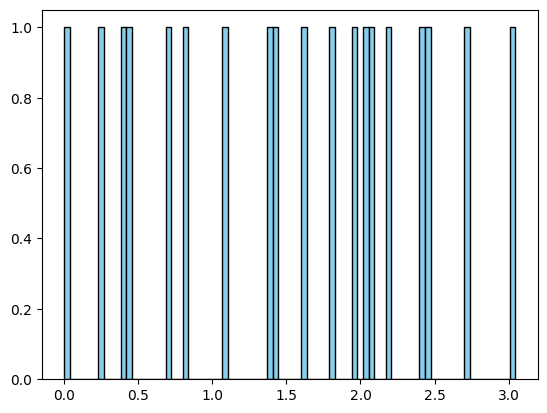

In [34]:
plt.hist(bins, bins=80, color='skyblue', edgecolor='black')
plt.show()
#LEAVE THE BINS LIKE THIS THIS SHOULD MAKE THIS WORK BETTER

#### function to reverse the bucket predicted from the model

In [35]:

def inverse_qcut(predictions, bins):
    """
    Convert qcut bucket predictions back
    into approximate numeric values.
    """

    restored_values = []

    for bucket in predictions:

        # Lower and upper edge of bucket
        lower = bins[bucket]
        upper = bins[bucket + 1]

        # Midpoint
        midpoint = (lower + upper) / 2

        restored_values.append(midpoint)

    return restored_values

### seperate the input columns from the output colums


In [ ]:
input_columns = bucketized_results.drop(["drinks_bucket", "log_drinks_bucket"], axis=1)
bucketized_output_column = bucketized_results["drinks_bucket"].copy()

## Select and train models

because the data is not spread in a linear fashion in the scatter graphs above I want to  try other models instead of linear regression:  
- Random Forest
- XGBoost
- Gradient Boosting
- LightGBM
- CatBoost 
- Poisson Regression 
- Negative Binomial Regression

### 🪓 make the train and test split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    input_columns,
    bucketized_output_column,
    test_size=0.2,
    random_state=42
)

### 🌴random forest

In [38]:
#make the model
forest = RandomForestClassifier()


# | Parameter           | Meaning                          |
# | ------------------- | -------------------------------- |
# | `n_estimators`      | number of trees                  |
# | `random_state`      | makes results reproducible       |
# | `max_depth`         | limits tree depth                |
# | `min_samples_split` | minimum samples before splitting |


#### RandomizedSearchCV

In [39]:
# Define the parameter distributions
param_distributions = {
    'n_estimators': np.arange(50, 300, 50),
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False],
    'random_state': 42
}

In [40]:
#Create the RandomizedSearchCV Instance
#Specify the number of iterations and scoring metric.

random_search = RandomizedSearchCV(
    estimator=forest,
    param_distributions=param_distributions,
    n_iter=50,  # Number of parameter settings to sample
    scoring='accuracy',
    cv=5,  # Number of cross-validation folds
    verbose=2,
    random_state=42,
    n_jobs=-1  # Use all available CPU cores
)



In [41]:
#train the model
forest.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric


---

NOTE:

1. Random Forest requires the SAME columns

The columns during prediction must:

have the same names
be in the same order
have the same meaning

as the training data.

---

#### Evaluating the random forest

##### comparing the output of the model to the bucketized drinks column

In [42]:
predictions = forest.predict(X_test)  

In [43]:
predictions[5:10].round(-2) # -2 = rounded to the nearest hundred

array([0, 0, 0, 0, 0])

In [44]:
bucketized_output_column.iloc[5:10].values

array([0, 1, 1, 1, 1])

##### RMSE

In [45]:
#cheking the performance of the model
rf_rmse = root_mean_squared_error(y_test, predictions)
rf_rmse

#the closer to 1 (which is the max value), the better.

5.700241540776005

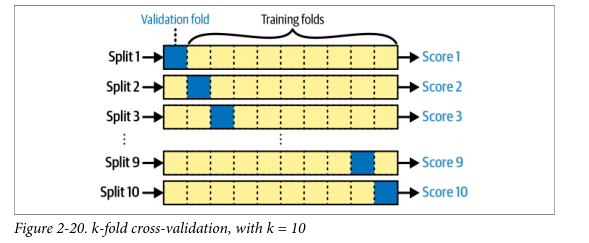

##### Cross validation

In [132]:
#One way to evaluate the decision tree model would be to
# to split the training set into a smaller training set and a
# validation set, then train your models against the smaller training set and evaluate
# them against the validation set

#how cross validation works
# . You split the
# training set into k nonoverlapping subsets called folds, then you train and evaluate
# your model k times, picking a different fold for evaluation every time (i.e., the
# validation fold) and using the other k – 1 folds for training. This process produces k
# evaluation scores


rf_rmses = -cross_val_score(forest, input_columns, bucketized_results["drinks_bucket"],
scoring="neg_root_mean_squared_error", cv=3)

##### Results of the evaluation

In [133]:
pd.Series(rf_rmses).describe()

count    3.000000
mean     5.491770
std      0.146866
min      5.362511
25%      5.411919
50%      5.461326
75%      5.556399
max      5.651472
dtype: float64

### XGBoost

In [134]:
xg_model = XGBClassifier()

#### RandomizedSearchCV

In [135]:
# Define the parameter distributions
param_distributions = {
    'n_estimators': np.arange(50, 300, 50),
    'max_depth': [None, 10, 20, 30],
    'learning_rate': [0,0.7,0.05],
    'random_state': 42
}

In [136]:
#Create the RandomizedSearchCV Instance
#Specify the number of iterations and scoring metric.

random_search = RandomizedSearchCV(
    estimator=xg_model,
    param_distributions=param_distributions,
    n_iter=50,  # Number of parameter settings to sample
    scoring='accuracy',
    cv=5,  # Number of cross-validation folds
    verbose=2,
    random_state=42,
    n_jobs=-1  # Use all available CPU cores
)



In [137]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y_train)

In [138]:
xg_model.fit(X_train, y_encoded)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

fix the issue


This error usually happens in machine learning classification models (commonly XGBoost or sometimes scikit-learn) when your target labels `y` are **not consecutive integers starting from 0**.

Your model expects classes like:

```python
[0, 1, 2, 3, ..., 12]
```

but your actual labels are:

```python
[0, 1, 3, 5, 6, 8, 9, 10, 12, 13, 14, 16, 17]
```

Notice the missing numbers:

* 2
* 4
* 7
* 11
* 15

The classifier wants labels to be remapped into consecutive indices.

---

 Fix

Use `LabelEncoder`.

```python
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)
```

Now your labels become:

```python
[0,1,2,3,4,5,6,7,8,9,10,11,12]
```

which matches what the model expects.

Then train using:

```python
model.fit(X, y_encoded)
```

---

 Why this happens

Suppose your original categories are:

```python
[0, 1, 3, 5]
```

Internally, classification algorithms often assume:

```python
class 0
class 1
class 2
class 3
```

because they allocate probabilities/output neurons by index.

So gaps in numbering confuse the model.

---

 If you need original labels back later

After prediction:

```python
pred = model.predict(X_test)

original_labels = encoder.inverse_transform(pred)
```

---

 Quick alternative

If your labels are numeric but arbitrary, you can remap manually:

```python
unique_classes = sorted(set(y))

mapping = {old:new for new, old in enumerate(unique_classes)}

y = [mapping[label] for label in y]
```

But `LabelEncoder` is cleaner.

---

 Check your labels first

```python
import numpy as np

print(np.unique(y))
```

This helps verify the issue quickly.


#### Evaluating XGBoost

##### comparing the output of the model to the bucketized drinks column

In [139]:
predictions = xg_model.predict(X_test)

In [140]:
predictions[5:10].round(-2) # -2 = rounded to the nearest hundred

array([0, 0, 0, 0, 0])

##### RMSE

In [141]:
xg_rmse = root_mean_squared_error(y_test, predictions)
xg_rmse

5.258533437475079

##### Cross validation

In [142]:
unique, counts = np.unique(bucketized_results["drinks_bucket"], return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(0): np.int64(9), np.int64(1): np.int64(108), np.int64(3): np.int64(17), np.int64(5): np.int64(35), np.int64(6): np.int64(21), np.int64(8): np.int64(50), np.int64(9): np.int64(17), np.int64(10): np.int64(40), np.int64(12): np.int64(6), np.int64(13): np.int64(21), np.int64(14): np.int64(12), np.int64(16): np.int64(4), np.int64(17): np.int64(5)}


In [143]:
xg_rmses = -cross_val_score(xg_model, input_columns,  encoder.fit_transform(bucketized_results["drinks_bucket"]), scoring="neg_root_mean_squared_error", cv=3)

##### Results of the evaluation

In [144]:
pd.Series(xg_rmses).describe()

count    3.000000
mean     3.609197
std      0.160515
min      3.457820
25%      3.525041
50%      3.592262
75%      3.684885
max      3.777508
dtype: float64

### Gradient boosting

In [145]:
gb_model = GradientBoostingClassifier()

#### RandomizedSearchCV

In [146]:
# Define the parameter distributions
param_distributions = {
    'n_estimators': np.arange(50, 300, 50),
    'min_samples_split': np.arange(2, 10, 1),
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 10,1],
    'learning_rate': [0,0.7,0.05],
    'random_state': 42 
}

In [147]:
#Create the RandomizedSearchCV Instance
#Specify the number of iterations and scoring metric.

random_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=param_distributions,
    n_iter=50,  # Number of parameter settings to sample
    scoring='accuracy',
    cv=5,  # Number of cross-validation folds
    verbose=2,
    random_state=42,
    n_jobs=-1  # Use all available CPU cores
)



In [148]:
gb_model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

#### Evaluating Gradient boosting

##### comparing the output of the model to the bucketized drinks column

In [149]:
predictions = gb_model.predict(X_test)

In [150]:
predictions[5:10].round(-2) # -2 = rounded to the nearest hundred

array([0, 0, 0, 0, 0])

##### RMSE

In [151]:
gb_rmse = root_mean_squared_error(y_test, predictions)
gb_rmse

6.0553007081949835

##### Cross validation

In [152]:
gb_rmses = -cross_val_score(gb_model, input_columns,  bucketized_results["drinks_bucket"],
scoring="neg_root_mean_squared_error", cv=3)

##### Results of the evaluation

In [153]:
pd.Series(gb_rmses).describe()

count    3.000000
mean     5.827752
std      0.090216
min      5.724850
25%      5.795001
50%      5.865151
75%      5.879202
max      5.893253
dtype: float64

### Lightgbm

In [154]:
lgbm_model = LGBMClassifier()

#### RandomizedSearchCV

In [155]:
# Define the parameter distributions
param_distributions = {
    'n_estimators': np.arange(50, 300, 50),
    'max_depth': [None, 10, 20, 30],
    'learning_rate': [0,0.7,0.05],
    'random_state': 42,
    'num_leaves': [31,100,1]
}

In [156]:
#Create the RandomizedSearchCV Instance
#Specify the number of iterations and scoring metric.

random_search = RandomizedSearchCV(
    estimator=lgbm_model,
    param_distributions=param_distributions,
    n_iter=50,  # Number of parameter settings to sample
    scoring='accuracy',
    cv=5,  # Number of cross-validation folds
    verbose=2,
    random_state=42,
    n_jobs=-1  # Use all available CPU cores
)



In [157]:
lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000076 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 185
[LightGBM] [Info] Number of data points in the train set: 276, number of used features: 5
[LightGBM] [Info] Start training from score -3.674491
[LightGBM] [Info] Start training from score -1.177750
[LightGBM] [Info] Start training from score -2.787188
[LightGBM] [Info] Start training from score -2.442347
[LightGBM] [Info] Start training from score -2.675962
[LightGBM] [Info] Start training from score -1.931521
[LightGBM] [Info] Start training from score -2.912351
[LightGBM] [Info] Start training from score -2.123893
[LightGBM] [Info] Start training from score -4.234107
[LightGBM] [Info] Start training from score -2.847812
[LightGBM] [Info] Start training from score -3.540959
[LightGBM] [Info] Start training from score -4.234107
[LightGBM] [Info] Start training from score -4.234107
[LightGBM] [W

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


#### Evaluating Lightgbm

##### comparing the output of the model to the bucketized drinks column

In [158]:
predictions = lgbm_model.predict(X_test)

In [159]:
predictions[5:10].round(-2) # -2 = rounded to the nearest hundred

array([0, 0, 0, 0, 0])

##### RMSE

In [160]:
lgbm_rmse = root_mean_squared_error(y_test, predictions)
lgbm_rmse


5.366293082685232

##### Cross validation

In [161]:
lgbm_rmses = -cross_val_score(lgbm_model, input_columns, bucketized_results["drinks_bucket"],
scoring="neg_root_mean_squared_error", cv=3)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000068 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 173
[LightGBM] [Info] Number of data points in the train set: 230, number of used features: 5
[LightGBM] [Info] Start training from score -3.646320
[LightGBM] [Info] Start training from score -1.161413
[LightGBM] [Info] Start training from score -3.040184
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.799022
[LightGBM] [Info] Start training from score -1.911719
[LightGBM] [Info] Start training from score -3.040184
[LightGBM] [Info] Start training from score -2.142242
[LightGBM] [Info] Start training from score -4.051785
[LightGBM] [Info] Start training from score -2.799022
[LightGBM] [Info] Start training from score -3.358638
[LightGBM] [Info] Start training from score -4.744932
[LightGBM] [Info] Start training from score -4.051785
[LightGBM] [W

##### Results of the evaluation

In [162]:
pd.Series(lgbm_rmses).describe()

count    3.000000
mean     5.639538
std      0.203075
min      5.407724
25%      5.566287
50%      5.724850
75%      5.755445
max      5.786040
dtype: float64

### catboost

In [163]:
cat_model = CatBoostClassifier()

#### RandomizedSearchCV

In [164]:
# Define the parameter distributions
param_distributions = {
    'n_estimators': np.arange(50, 300, 50),
    'min_samples_split': np.arange(2, 10, 1),
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 10,1],
    'learning_rate': [0,0.7,0.05],
    'n_estimators': [0,100,2],
    'random_state': 42,
    'num_leaves':  [0,100,2]
}

In [165]:
#Create the RandomizedSearchCV Instance
#Specify the number of iterations and scoring metric.

random_search = RandomizedSearchCV(
    estimator=cat_model,
    param_distributions=param_distributions,
    n_iter=50,  # Number of parameter settings to sample
    scoring='accuracy',
    cv=5,  # Number of cross-validation folds
    verbose=2,
    random_state=42,
    n_jobs=-1  # Use all available CPU cores
)



In [166]:
# Train model
cat_model.fit(X_train, y_train)

Learning rate set to 0.074099
0:	learn: 2.5230503	total: 4.41ms	remaining: 4.4s
1:	learn: 2.4717355	total: 8.46ms	remaining: 4.22s
2:	learn: 2.4366883	total: 12.6ms	remaining: 4.18s
3:	learn: 2.3905023	total: 13.7ms	remaining: 3.41s
4:	learn: 2.3616285	total: 17.9ms	remaining: 3.56s
5:	learn: 2.3339854	total: 22.1ms	remaining: 3.67s
6:	learn: 2.3060936	total: 26.4ms	remaining: 3.75s
7:	learn: 2.2806566	total: 31.3ms	remaining: 3.88s
8:	learn: 2.2540694	total: 36.2ms	remaining: 3.98s
9:	learn: 2.2275300	total: 40.7ms	remaining: 4.03s
10:	learn: 2.2054262	total: 45.4ms	remaining: 4.08s
11:	learn: 2.1805934	total: 50.4ms	remaining: 4.15s
12:	learn: 2.1569523	total: 55ms	remaining: 4.18s
13:	learn: 2.1394375	total: 59.4ms	remaining: 4.18s
14:	learn: 2.1209974	total: 63.5ms	remaining: 4.17s
15:	learn: 2.1038071	total: 68ms	remaining: 4.18s
16:	learn: 2.0873209	total: 71.9ms	remaining: 4.16s
17:	learn: 2.0692329	total: 75.7ms	remaining: 4.13s
18:	learn: 2.0514217	total: 79.7ms	remaining: 4.1

CatBoostClassifier()

#### Evaluating the catboost

##### comparing the output of the model to the bucketized drinks column

In [167]:
predictions = cat_model.predict(X_test)

In [168]:
predictions[5:10].round(-2) # -2 = rounded to the nearest hundred

array([[0],
       [0],
       [0],
       [0],
       [0]])

##### RMSE

In [169]:
lin_rmse = root_mean_squared_error(y_test, predictions)


##### Cross validation

In [170]:
cat_rmses = -cross_val_score(cat_model,
    input_columns,bucketized_results["drinks_bucket"],
scoring="neg_root_mean_squared_error", cv=3)

Learning rate set to 0.073413
0:	learn: 2.5266116	total: 3.52ms	remaining: 3.51s
1:	learn: 2.4844311	total: 6.52ms	remaining: 3.25s
2:	learn: 2.4414271	total: 9.53ms	remaining: 3.17s
3:	learn: 2.4003130	total: 12.6ms	remaining: 3.14s
4:	learn: 2.3712738	total: 16.4ms	remaining: 3.26s
5:	learn: 2.3311158	total: 20.2ms	remaining: 3.34s
6:	learn: 2.2992209	total: 23.9ms	remaining: 3.39s
7:	learn: 2.2730323	total: 27.9ms	remaining: 3.46s
8:	learn: 2.2465393	total: 31.9ms	remaining: 3.52s
9:	learn: 2.2192485	total: 36.1ms	remaining: 3.57s
10:	learn: 2.1920277	total: 40.5ms	remaining: 3.64s
11:	learn: 2.1666620	total: 45ms	remaining: 3.71s
12:	learn: 2.1455708	total: 49ms	remaining: 3.72s
13:	learn: 2.1230271	total: 53ms	remaining: 3.73s
14:	learn: 2.0998094	total: 56.9ms	remaining: 3.74s
15:	learn: 2.0785811	total: 60.8ms	remaining: 3.74s
16:	learn: 2.0595755	total: 64.7ms	remaining: 3.74s
17:	learn: 2.0424473	total: 68.5ms	remaining: 3.74s
18:	learn: 2.0235414	total: 72.2ms	remaining: 3.73

##### Results of the evaluation

In [171]:
pd.Series(cat_rmses).describe()

count    3.000000
mean     5.695646
std      0.094844
min      5.591142
25%      5.655337
50%      5.719532
75%      5.747898
max      5.776263
dtype: float64

### Poisson Regression

In [172]:
poi_model = PoissonRegressor()


#### RandomizedSearchCV

In [173]:
# Define the parameter distributions
param_distributions = {
    'alpha': [1, 10,1],
    'max_iter': [100, 100,20],
    'solver': ['lbfgs', 'newton-cholesky']
}

In [174]:
#Create the RandomizedSearchCV Instance
#Specify the number of iterations and scoring metric.

random_search = RandomizedSearchCV(
    estimator=poi_model,
    param_distributions=param_distributions,
    n_iter=50,  # Number of parameter settings to sample
    scoring='accuracy',
    cv=5,  # Number of cross-validation folds
    verbose=2,
    random_state=42,
    n_jobs=-1  # Use all available CPU cores
)



In [175]:
poi_model.fit(X_train, y_train)

,"alpha alpha: float, default=1Constant that multiplies the L2 penalty term and determines theregularization strength. ``alpha = 0`` is equivalent to unpenalizedGLMs. In this case, the design matrix `X` must have full column rank(no collinearities).Values of `alpha` must be in the range `[0.0, inf)`.",1.0
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the linear predictor (`X @ coef + intercept`).",True
,"solver solver: {'lbfgs', 'newton-cholesky'}, default='lbfgs'Algorithm to use in the optimization problem:'lbfgs' Calls scipy's L-BFGS-B optimizer.'newton-cholesky' Uses Newton-Raphson steps (in arbitrary precision arithmetic equivalent to iterated reweighted least squares) with an inner Cholesky based solver. This solver is a good choice for `n_samples` >> `n_features`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features` because it explicitly computes the Hessian matrix. .. versionadded:: 1.2",'lbfgs'
,"max_iter max_iter: int, default=100The maximal number of iterations for the solver.Values must be in the range `[1, inf)`.",100
,"tol tol: float, default=1e-4Stopping criterion. For the lbfgs solver,the iteration will stop when ``max{|g_j|, j = 1, ..., d} <= tol``where ``g_j`` is the j-th component of the gradient (derivative) ofthe objective function.Values must be in the range `(0.0, inf)`.",0.0001
,"warm_start warm_start: bool, default=FalseIf set to ``True``, reuse the solution of the previous call to ``fit``as initialization for ``coef_`` and ``intercept_`` .",False
,"verbose verbose: int, default=0For the lbfgs solver set verbose to any positive number for verbosity.Values must be in the range `[0, inf)`.",0


#### Evaluating the Poisson Regression

##### comparing the output of the model to the bucketized drinks column

In [176]:
y_pred = poi_model.predict(X_test)

In [177]:
predictions[5:10].round(-2) # -2 = rounded to the nearest hundred

array([[0],
       [0],
       [0],
       [0],
       [0]])

##### RMSE

In [178]:
poi_rmse = root_mean_squared_error(y_test, y_pred)


##### Cross validation

In [179]:
poi_rmses = -cross_val_score(poi_model,
    input_columns, bucketized_results["drinks_bucket"],
scoring="neg_root_mean_squared_error", cv=3)

##### Results of the evaluation

In [180]:
pd.Series(poi_rmses).describe()

count    3.000000
mean     4.602906
std      0.039143
min      4.569952
25%      4.581272
50%      4.592593
75%      4.619383
max      4.646173
dtype: float64

##fix the structure of this file, fix the models that are not train test plitted and make all the models used classification models THEN finetune the best model

### how to interpet cross val results
---

the values are relatiove to what i am predicting. so in am trying to predict numbers 1-4

---

mean This is the model’s average prediction error.

Smaller is better.

---

std
This tells you how stable the model is across folds.

low std → consistent performance
high std → unstable model



## Analyzing the Best Models and Their Errors

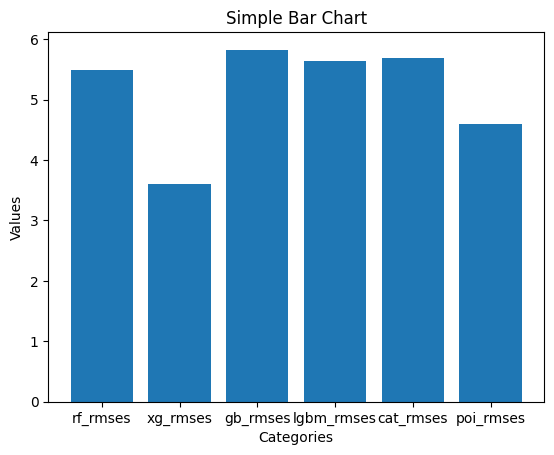

In [181]:
import matplotlib.pyplot as plt

# categories
names = ["rf_rmses", "xg_rmses", "gb_rmses", "lgbm_rmses", "cat_rmses", "poi_rmses"]

# values
values = [np.mean(rf_rmses),
          np.mean(xg_rmses),
          np.mean(gb_rmses),
          np.mean(lgbm_rmses),
          np.mean(cat_rmses),
          np.mean(poi_rmses)]

# create bar chart
plt.bar(names, values)

# labels and title
plt.xlabel("Categories")
plt.ylabel("Values")
plt.title("Simple Bar Chart")

# show chart
plt.show()

from this barchat it seem th gb is the best model

## Evaluate Your System 

### Evaluate Your System on the Test Set

In [183]:
final_predictions = gb_model.predict(input_columns)
final_rmse = root_mean_squared_error(bucketized_output_column, final_predictions)
print(final_rmse)

2.70801280154532


### 95% confidence interval

A 95% confidence interval is like saying, “I’m pretty sure the real answer is somewhere in this range.”

In [185]:
from scipy import stats

def rmse(squared_errors):
    return np.sqrt(np.mean(squared_errors))
confidence = 0.95
squared_errors = (final_predictions - bucketized_output_column) ** 2
boot_result = stats.bootstrap(
    [squared_errors], 
    rmse,
    confidence_level=confidence, 
    random_state=42)


rmse_lower, rmse_upper = boot_result.confidence_interval

In [186]:
rmse_lower

np.float64(2.2511371914609675)

In [187]:
rmse_upper

np.float64(3.249930150690675)

the value (final_rmse) is good because it is inbetween the range